In [212]:
import yfinance as yf
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [214]:
tickers = [
    "RELIANCE.NS",    
    "HDFCBANK.NS",   
    "ITC.NS",         
    "MARUTI.NS",      
    "RCOM.NS",       
    "BALLARPUR.NS"   
]

In [216]:
data = yf.download(
    tickers,
    start="2017-01-01",
    end="2023-06-23"
)["Close"]

[*********************100%***********************]  6 of 6 completed


In [218]:
data = data[
    [
        "RELIANCE.NS",
        "HDFCBANK.NS",
        "ITC.NS",
        "MARUTI.NS",
        "RCOM.NS",
        "BALLARPUR.NS"
    ]
]

In [220]:
data = data.ffill().dropna()

In [222]:
# Returns
returns = data.pct_change().dropna()

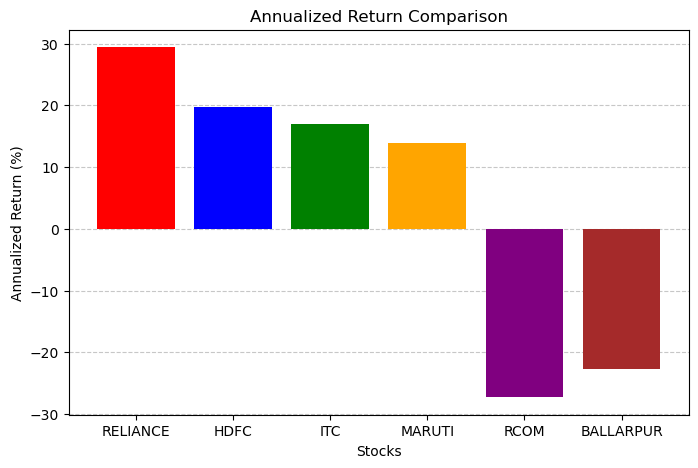

In [224]:
stocks = ["RELIANCE", "HDFC", "ITC", "MARUTI", "RCOM", "BALLARPUR"]

annualized_return = returns.mean() * 252 * 100

# Convert to list
return_values = annualized_return.values

# Plot
plt.figure(figsize=(8,5))
plt.bar(
    stocks,
    return_values,
    color=['red','blue','green','orange','purple','brown']
)
plt.title("Annualized Return Comparison")
plt.xlabel("Stocks")
plt.ylabel("Annualized Return (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.show()

In [226]:
# Most selected stocks show positive returns
# Reliance gives highest return
# HDFC, ITC, Maruti have moderate and stable returns
# RCOM and Ballarpur show negative returns
# Returns are similar among good stocks

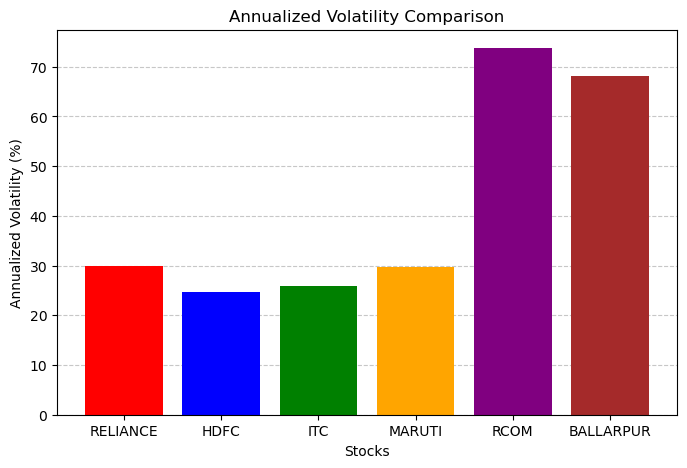

In [228]:
stocks = ["RELIANCE", "HDFC", "ITC", "MARUTI", "RCOM", "BALLARPUR"]

volatility = returns.std() * (252**0.5) * 100

# Convert to list
risk_values = volatility.values

# Plot
plt.figure(figsize=(8,5))
plt.bar(
    stocks,
    risk_values,
    color=['red','blue','green','orange','purple','brown']
)
plt.title("Annualized Volatility Comparison")
plt.xlabel("Stocks")
plt.ylabel("Annualized Volatility (%)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.show()

In [230]:
# RCOM has the highest risk (most volatile)
# Ballarpur also shows very high risk
# Reliance and Maruti have moderate risk
# HDFC and ITC have lowest risk (more stable)
# Most stocks have lower risk except RCOM and Ballarpur
# Low-risk stocks are better for safe investment

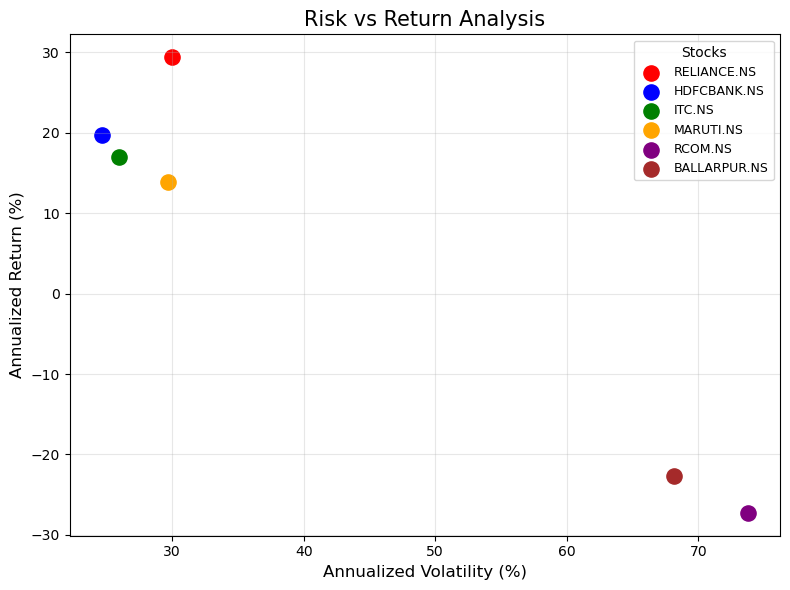

In [232]:
mean_returns = returns.mean() * 252 * 100
volatility = returns.std() * (252**0.5) * 100

plt.figure(figsize=(8,6))

colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

# Scatter Plot
for i in range(len(mean_returns)):
    plt.scatter(
        volatility.iloc[i],
        mean_returns.iloc[i],
        color=colors[i],
        s=120,
        label=mean_returns.index[i]
    )
plt.xlabel("Annualized Volatility (%)", fontsize=12)
plt.ylabel("Annualized Return (%)", fontsize=12)
plt.title("Risk vs Return Analysis", fontsize=15)
plt.legend(title="Stocks", fontsize=9, loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [234]:
# Most selected stocks have low risk and positive returns
# Reliance offers the highest return with relatively low risk
# HDFC, ITC, Maruti are stable stocks
# RCOM and Ballarpur have high risk and negative returns
# Good to invest in low-risk stable stocks

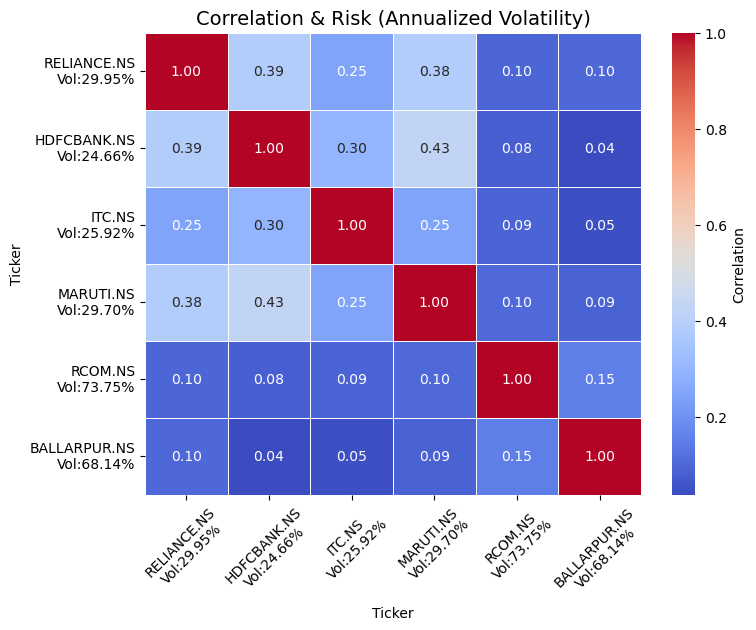

In [236]:
# Correlation
corr = returns.corr()
volatility = returns.std() * (252**0.5) * 100

labels = [
    f"{col}\nVol:{volatility[col]:.2f}%"
    for col in corr.columns
]

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Correlation'}
)
plt.title("Correlation & Risk (Annualized Volatility)", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [240]:
# Most stocks show low correlation, indicating independent movement.
# Some pairs like HDFC–Maruti and Reliance–HDFC show moderate correlation.
# RCOM and Ballarpur are highly volatile, indicating higher investment risk.
# Low correlation combined with varying volatility supports portfolio diversification.

### Risk Segmentation and Grouping Analysis

In [276]:
summary = pd.DataFrame({
    "Annualized Return (%)": returns.mean() * 252 * 100,
    "Annualized Volatility (%)": returns.std() * (252**0.5) * 100
}).round(2)

summary

,Annualized Return (%),Annualized Volatility (%)
Ticker,,
RELIANCE.NS,29.40,29.95
HDFCBANK.NS,19.72,24.66
ITC.NS,17.02,25.92
MARUTI.NS,13.81,29.70
RCOM.NS,-27.27,73.75
BALLARPUR.NS,-22.69,68.14


In [280]:
summary["Risk Level"] = pd.cut(
    summary["Annualized Volatility (%)"],
    bins=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

summary = summary.round(2)
summary

,Annualized Return (%),Annualized Volatility (%),Risk Level
Ticker,,,
RELIANCE.NS,29.40,29.95,Low Risk
HDFCBANK.NS,19.72,24.66,Low Risk
ITC.NS,17.02,25.92,Low Risk
MARUTI.NS,13.81,29.70,Low Risk
RCOM.NS,-27.27,73.75,High Risk
BALLARPUR.NS,-22.69,68.14,High Risk


In [290]:
grouped = summary.groupby("Risk Level", observed=True).mean().round(2)
grouped

,Annualized Return (%),Annualized Volatility (%)
Risk Level,,
Low Risk,19.99,27.56
High Risk,-24.98,70.94


In [292]:
summary.groupby("Risk Level", observed=True).agg({
    "Annualized Return (%)": ["mean", "max", "min"],
    "Annualized Volatility (%)": ["mean", "max", "min"]
}).round(2)

Annualized Return (%)               Annualized Volatility (%)  \
                            mean    max    min                      mean   
Risk Level                                                                 
Low Risk                   19.99  29.40  13.81                     27.56   
High Risk                 -24.98 -22.69 -27.27                     70.94   

                          
              max    min  
Risk Level                
Low Risk    29.95  24.66  
High Risk   73.75  68.14

In [294]:
# Count of Stocks in Each Group
summary.groupby("Risk Level", observed=True).size()

Risk Level
Low Risk     4
High Risk    2
dtype: int64

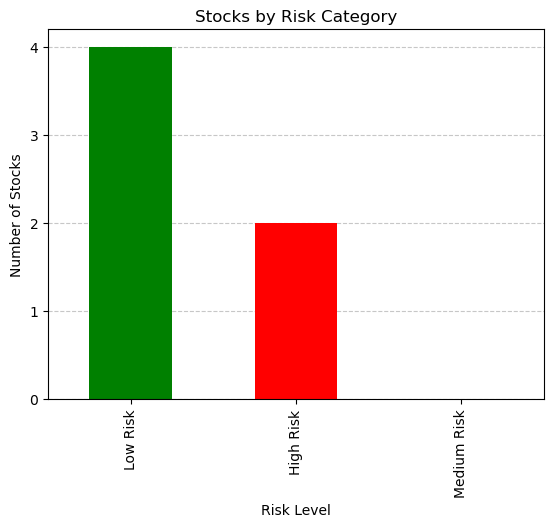

In [274]:
summary["Risk Level"].value_counts().plot(
    kind="bar",
    color=["green", "red", "orange"]
)

plt.title("Stocks by Risk Category")
plt.xlabel("Risk Level")
plt.ylabel("Number of Stocks")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)
plt.yticks(range(0, 5))
plt.show()

In [254]:
# Most stocks fall under the Low Risk category, indicating relatively stable performance
# A smaller number of stocks are in the High Risk category with higher volatility
# No stocks fall under the Medium Risk category
# This classification helps investors make informed decisions between safe and high-risk investments

### ANOVA Analysis of Stock Returns

In [256]:
g1 = returns["RELIANCE.NS"]
g2 = returns["HDFCBANK.NS"]
g3 = returns["ITC.NS"]
g4 = returns["MARUTI.NS"]
g5 = returns["RCOM.NS"]
g6 = returns["BALLARPUR.NS"]

In [258]:
f_stat, p_value = stats.f_oneway(g1, g2, g3, g4, g5, g6)

In [260]:
print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.6478981990734214
P-value: 0.14363632838559337


In [262]:
if p_value < 0.05:
    print("Reject null hypothesis: Significant difference exists in stock returns.")
else:
    print("Fail to reject null hypothesis: No significant difference in stock returns.")

Fail to reject null hypothesis: No significant difference in stock returns.


In [154]:
# Since the p-value is greater than 0.05, we fail to reject the null hypothesis, indicating that there is no significant difference in stock returns.
